# Model experiments & documentation

This notebook records the EDA, feature engineering, training, and validation workflows for AuditAI's synthetic audit dataset. It also persists the trained artifacts into `backend/app/ai` so the backend fraud and risk services can load the latest models.

In [1]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

## Dataset loading & snapshot

The synthetic dataset lives in `data/processed/synthetic_enterprise_audit.csv`. It contains per-transaction labels such as `anomaly_flag`, `fraud_score`, `risk_score`, and `risk_level` plus vendor, category, and currency attributes.

In [2]:
DATA_PATH = Path("../data/processed/synthetic_enterprise_audit.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["fraud_score"] = pd.to_numeric(df.get("fraud_score", 0), errors="coerce").clip(0, 1)
df["risk_score"] = pd.to_numeric(df.get("risk_score", 0), errors="coerce").clip(0, 100)
print("Loaded", df.shape, "rows and columns")
print("Unique organizations", df["organization_id"].nunique())
df.head()

Loaded (50000, 27) rows and columns
Unique organizations 5


,transaction_id,organization_id,organization_name,user_id,date,amount,currency,vendor_id,vendor_name,category,...,risk_level,duplicate_flag,missing_invoice_flag,unusual_vendor_flag,weekend_or_odd_time_flag,vendor_risk_score,user_tenure_days,previous_txn_count,approval_status,source_file_id
0,55ece3e8-c0cd-4dfa-9ba8-8e4631671c7c,c087c8e5-df32-48c7-a7b8-7242d24c5934,"Mcclain, Miller and Henderson",a5f2def9-ef58-4d3f-9899-8d16d1b1503a,2025-10-18 19:51:46,2971.18,EUR,fae02880-cfad-4d72-90f7-4aae2d707ffc,Spence PLC,Software,...,Low,0,0,0,1,0.36,1580,0,Approved,2a08bf0f-db93-4565-9a75-a8d1a320120b
1,75e572d4-2e54-4211-b9fd-fda83f2b1482,768a9a30-d1e5-443b-86c4-096cb9b7a733,Wagner Inc,e9df9862-c4a7-4f2c-92d4-6e7b55bb0d3e,2026-01-13 20:47:43,1574.57,EUR,8c74e4fd-0511-41a1-8635-03f7fdf201a5,"Huff, Novak and House",Software,...,Low,0,0,0,0,0.62,3579,4,Approved,90ed2341-983f-481a-8837-ba39acd29f8e
2,57329947-fc56-43e9-8014-a5c3810e3095,64151abe-5215-4abd-831f-44c47301498d,"Henderson, Ramirez and Lewis",dbc61a71-ec0c-48f5-b53b-e62ae5e8c082,2026-03-07 23:35:12,3455.38,USD,87ecb8b6-f62b-4496-a1c2-9fe136d5c933,"Lawson, Morris and Ramos",Equipment,...,Low,0,0,0,1,0.32,2970,0,Approved,c3358783-5205-4f1b-afc0-51b3949e0efd
3,a0f5a4e0-4a1f-4e20-b3f7-b06f1a0a60df,768a9a30-d1e5-443b-86c4-096cb9b7a733,Wagner Inc,2d5935e0-2a45-4096-aee9-e6293428f0f7,2025-09-15 17:34:15,8291.86,EUR,8c74e4fd-0511-41a1-8635-03f7fdf201a5,"Huff, Novak and House",Equipment,...,Low,0,0,0,0,0.62,1586,2,Approved,67d6f1ce-9f2a-4abe-b9b1-afde110b3a30
4,7376e183-43e8-4db9-8236-8839461f33c8,c087c8e5-df32-48c7-a7b8-7242d24c5934,"Mcclain, Miller and Henderson",9b4b1477-a912-411a-8c2e-4bea60fc45a1,2025-09-17 08:18:33,1430.60,EUR,935f902e-89cd-467e-aed3-b694e0ff5fb6,Romero Inc,Equipment,...,Low,0,1,0,0,0.22,541,7,Approved,75f333fa-838a-4734-92ea-e5e8ceb26d67


Anomaly rate: 0.02022

Risk level mix (normalized):
risk_level
Low     0.97978
High    0.02022
Name: proportion, dtype: float64

Top categories:
category
Equipment          10067
Travel             10053
Software           10015
Consulting          9986
Office Supplies     9879
Name: count, dtype: int64

Highest-volume vendors:
vendor_name
Bush Inc                    1078
Fletcher Inc                1074
Jones, Reid and Ferguson    1064
Jones-Beck                  1055
Rodriguez Ltd               1049
Name: count, dtype: int64


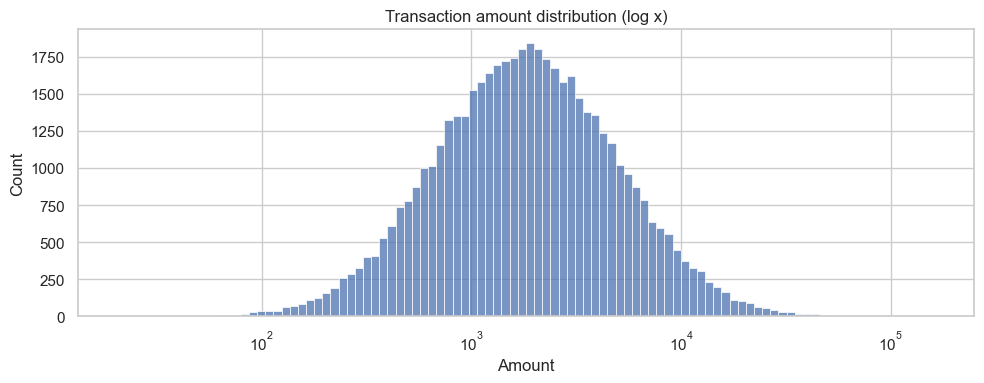

In [3]:
print("Anomaly rate:", df["anomaly_flag"].mean())
print("\nRisk level mix (normalized):")
print(df["risk_level"].fillna("Unknown").value_counts(normalize=True))
print("\nTop categories:")
print(df["category"].value_counts().head())
print("\nHighest-volume vendors:")
print(df["vendor_name"].value_counts().head())
plt.figure()
sns.histplot(df["amount"], bins=100, log_scale=(True, False))
plt.title("Transaction amount distribution (log x)")
plt.xlabel("Amount")
plt.tight_layout()
plt.show()

## Feature engineering decisions

We build a blended feature matrix that includes normalized numeric indicators, vendor risk, historical user/workflow flags, and one-hot encodings for categorical controls (category, payment method, and approval status).

In [4]:
NUMERIC_FEATURES = [
    "amount",
    "tax_amount",
    "vendor_risk_score",
    "user_tenure_days",
    "previous_txn_count",
    "fraud_score",
]
CATEGORICAL_FEATURES = ["category", "payment_method", "approval_status"]
FLAG_COLUMNS = [
    "duplicate_flag",
    "missing_invoice_flag",
    "unusual_vendor_flag",
    "weekend_or_odd_time_flag",
]

def build_feature_matrix(source: pd.DataFrame) -> pd.DataFrame:
    df = source.copy()
    for col in NUMERIC_FEATURES + FLAG_COLUMNS:
        df[col] = pd.to_numeric(df.get(col, 0), errors="coerce").fillna(0)
    dummies = []
    for col in CATEGORICAL_FEATURES:
        if col in df:
            dummies.append(pd.get_dummies(df[col].fillna("Unknown").astype(str), prefix=col, drop_first=True))
    feature_frames = [df[NUMERIC_FEATURES + FLAG_COLUMNS]] + dummies
    X = pd.concat(feature_frames, axis=1, copy=False).fillna(0)
    return X

X_full = build_feature_matrix(df)
X_full.shape

C:\Users\hjiaz tr\AppData\Local\Temp\ipykernel_21192\2683991588.py:26: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  X = pd.concat(feature_frames, axis=1, copy=False).fillna(0)


(50000, 19)

In [5]:
y_fraud = df["anomaly_flag"].fillna(0).astype(int)
y_risk = df["risk_score"]
print("Fraud target balance:", y_fraud.value_counts(normalize=True).to_dict())

Fraud target balance: {0: 0.97978, 1: 0.02022}


In [6]:
X_train, X_test, y_f_train, y_f_test = train_test_split(
    X_full, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)
X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X_full, y_risk, test_size=0.2, random_state=42
)

In [7]:
fraud_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)
fraud_clf.fit(X_train, y_f_train)
y_f_pred = fraud_clf.predict(X_test)
y_f_proba = fraud_clf.predict_proba(X_test)[:, 1]
print(classification_report(y_f_test, y_f_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_f_test, y_f_pred))
print("ROC AUC:", roc_auc_score(y_f_test, y_f_proba))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000      9798
           1      1.000     1.000     1.000       202

    accuracy                          1.000     10000
   macro avg      1.000     1.000     1.000     10000
weighted avg      1.000     1.000     1.000     10000

Confusion matrix:
 [[9798    0]
 [   0  202]]
ROC AUC: 1.0


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = []
for train_idx, val_idx in cv.split(X_full, y_fraud):
    temp_clf = RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )
    temp_clf.fit(X_full.iloc[train_idx], y_fraud.iloc[train_idx])
    y_val = temp_clf.predict(X_full.iloc[val_idx])
    cv_f1.append(f1_score(y_fraud.iloc[val_idx], y_val, zero_division=0))
print("5-fold CV F1 mean:", np.mean(cv_f1))

5-fold CV F1 mean: 1.0


In [9]:
artifact_dir = Path("../backend/app/ai/fraud_model/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(fraud_clf, artifact_dir / "fraud_classifier.joblib")
fraud_metrics = {
    "classification": classification_report(y_f_test, y_f_pred, output_dict=True),
    "roc_auc": float(roc_auc_score(y_f_test, y_f_proba)),
    "cv_f1": float(np.mean(cv_f1)),
}
with open(artifact_dir / "fraud_metrics.json", "w", encoding="utf-8") as fp:
    json.dump(fraud_metrics, fp, indent=2)
print("Fraud classifier artifacts persisted to", artifact_dir)

Fraud classifier artifacts persisted to ..\backend\app\ai\fraud_model\artifacts


## Risk regression baseline

We combine the deterministic rules (vendor risk, fraud flags) with ML refinement so the final risk score is anchored to explainable heuristics but tuned by the regressor's predictions.

MAE: 0.016604961673601558
R2: 0.999931219035652


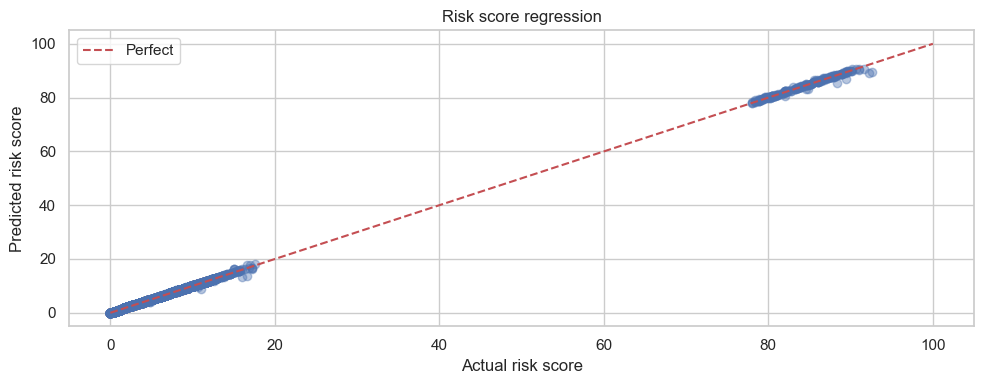

In [10]:
risk_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
)
risk_model.fit(X_r_train, y_r_train)
y_r_pred = risk_model.predict(X_r_test)
mae_val = mean_absolute_error(y_r_test, y_r_pred)
r2_val = r2_score(y_r_test, y_r_pred)
print("MAE:", mae_val)
print("R2:", r2_val)
plt.figure()
plt.scatter(y_r_test, y_r_pred, alpha=0.4)
plt.plot([0, 100], [0, 100], "r--", label="Perfect")
plt.xlabel("Actual risk score")
plt.ylabel("Predicted risk score")
plt.title("Risk score regression")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
risk_artifact = Path("../backend/app/ai/risk_model/artifacts")
risk_artifact.mkdir(parents=True, exist_ok=True)
joblib.dump(risk_model, risk_artifact / "risk_regressor.joblib")
risk_metrics = {"mae": float(mae_val), "r2": float(r2_val)}
with open(risk_artifact / "risk_metrics.json", "w", encoding="utf-8") as fp:
    json.dump(risk_metrics, fp, indent=2)
print("Risk model stored under", risk_artifact)

Risk model stored under ..\backend\app\ai\risk_model\artifacts


In [12]:
level_bins = pd.cut(
    y_r_pred, bins=[-0.1, 30, 70, 100], labels=["Low", "Medium", "High"]
)
predicted_levels = level_bins.value_counts().sort_index()
print("Predicted risk levels:", predicted_levels.to_dict())

Predicted risk levels: {'Low': 9804, 'Medium': 0, 'High': 196}


## Next steps & observations

1. Explore vendor-level time series features (rolling averages, Benford statistics, duplicate detection) and add them to `build_feature_matrix`.
2. Add calibration plots for the fraud classifier and capture feature importances in the notebook for review.
3. Evaluate the risk regressor on an equalized dataset per organization to detect potential bias, then instrument this notebook with those comparisons.
4. Keep this notebook as the source of truth for anomaly/risk modeling decisions before fine-tuning on pilot customer data.